In [124]:
import torch

import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from IPython.display import HTML

from sincnet.model import SincNet
from sincnet.mulaw import MuLawQuant, mu_law_compand, mu_law_expand
from datasets.utils.waveform import WaveformLoader
from training.utils.stft import TorchSTFT

In [125]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [126]:
#SAMPLE_RATE = 44100
SAMPLE_RATE = 16000
audio_loader = WaveformLoader(sample_rate=SAMPLE_RATE)

Initializing PreprocessingWaveformLoader with sample rate sr:16000...


In [ ]:
params = {
    "fs": SAMPLE_RATE,
    "fps": 128,
    "n_bins": 256,
    "scale": "mel",
    "component": "complex",
    "causal": False,
    "decoder_type": "fast"
}

sinc : SincNet = (
    SincNet(**params)
    .eval()
    .to(device)
)

In [ ]:
n_fft = 1024
win_length = 1024
hop_length = win_length // 4
stft = TorchSTFT(sample_rate=params["fs"], n_fft=n_fft, hop_length=hop_length, win_length=win_length).to(device)

## 1 - Invertibility Test

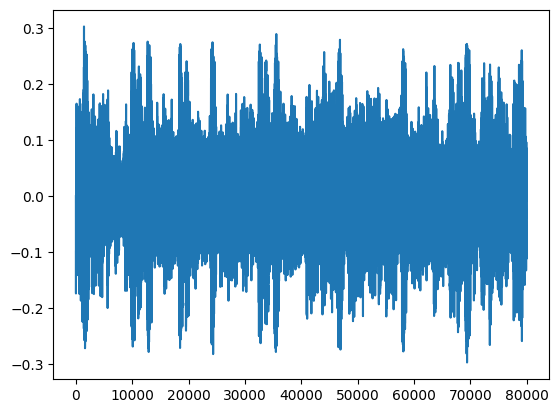

In [ ]:
audio_pathes = {
    1:"audio/invertibility/p232_001.wav",
    2:"audio/invertibility/p232_002.wav",
    3:"audio/invertibility/15033000.mp3",
    4:"audio/invertibility/16366200.mp3",
    5:"audio/invertibility/16129994.mp3",
    6:"audio/invertibility/16176213.mp3",
}

audio_path = audio_pathes[4]

waveform = audio_loader.load_segment(audio_path, offset=15, duration=5, nchannels=1)
loudness = audio_loader.measure_loudness(waveform)
waveform = audio_loader.normalise_loudness(waveform, loudness, target_lufs=-23)

plt.plot(waveform[0])
ipd.Audio(waveform, rate=SAMPLE_RATE, autoplay=False)

wav_in tensor(-0.2968) tensor(0.3027) torch.Size([1, 80000])
wav_ou tensor(-0.2968) tensor(0.3027) torch.Size([1, 80000])
pr-spec: tensor(-0.1065) tensor(0.1013)
cq-spec: tensor(1) tensor(253)
dq-spec: tensor(-0.1064) tensor(0.1004)


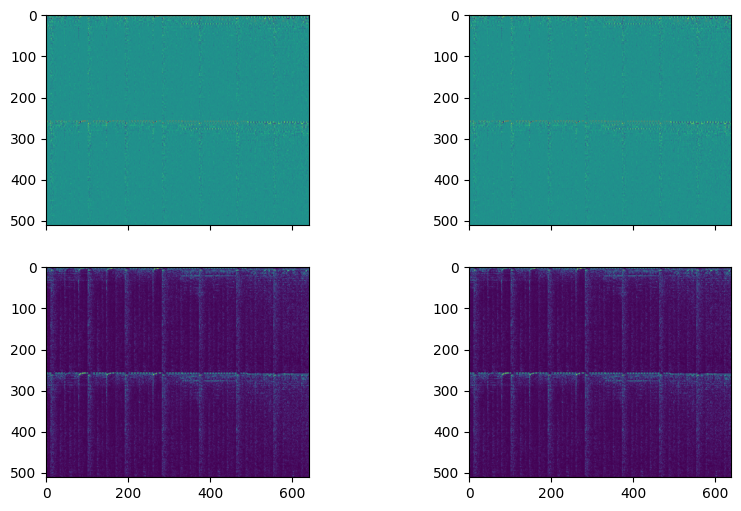

In [ ]:
eps=1e-8
q_bits = 8
quantizer = MuLawQuant(q_bits=q_bits)


with torch.no_grad():    
    # trnsform the waveform into tensor
    wav = torch.from_numpy(waveform).to(device).float()
    print("wav_in", wav.min(), wav.max(), wav.shape)

    #encode and decode waveform
    spec = s = sinc.encode(wav)
    #s[:, :, 96:] = 0
    reconstructed_wav = sinc.decode(s)

    # predictions = sinc(wav)
    # reconstructed_wav = predictions["waveform"]

    print("wav_ou", reconstructed_wav.min(), reconstructed_wav.max(), reconstructed_wav.shape)
    print("pr-spec:", s.min(), s.max())

    #apply quantization
    sq, scale = quantizer.quantize(s)
    print("cq-spec:", sq.min(), sq.max())
    sr = quantizer.dequantize(sq, scale)
    print("dq-spec:", sr.min(), sr.max())
    detokenized_wav = sinc.decode(sr)

    #apply mu-law-companding for visualization
    s = mu_law_compand(s, q_bits=q_bits)
    sr = mu_law_compand(sr, q_bits=q_bits)

    m = torch.sqrt(s[:,0]**2 + s[:,1]**2) if s.shape[1] > 1 else s[:,0].abs()
    mr = torch.sqrt(sr[:,0]**2 + sr[:,1]**2) if sr.shape[1] > 1 else sr[:,0].abs()

    # reduce to 2D for visualization (average over channels mono/stereo and frequencies)
    s = s.flatten(1,2).mean(dim=0)
    sr = sr.flatten(1,2).mean(dim=0)


f, axes = plt.subplots(2, 2, figsize=(10, 6), sharex="all")

y = s.detach().numpy()
yr = sr.detach().numpy()

axes[0,0].imshow(y)
axes[1,0].imshow(np.abs(y))
#axes[2,0].imshow(m[0].detach().numpy())

axes[0,1].imshow(yr)
axes[1,1].imshow(np.abs(yr))
#axes[2,1].imshow(mr[0].detach().numpy())

# Create your Audio objects
audio1 = ipd.Audio(reconstructed_wav, rate=SAMPLE_RATE, autoplay=False)
audio2 = ipd.Audio(detokenized_wav, rate=SAMPLE_RATE, autoplay=False)
# Embed them in HTML with flexbox for horizontal layout
html_content = f"""
<div style="display:flex; justify-content:space-around;">
    <div>
        <h3>Reconstructed waveform</h3>
        {audio1._repr_html_()}
    </div>
    <div>
        <h3>Dequantized waveform</h3>
        {audio2._repr_html_()}
    </div>
</div>
"""
# Display the HTML
display(HTML(html_content))

Text(0.5, 1.0, 'difference')

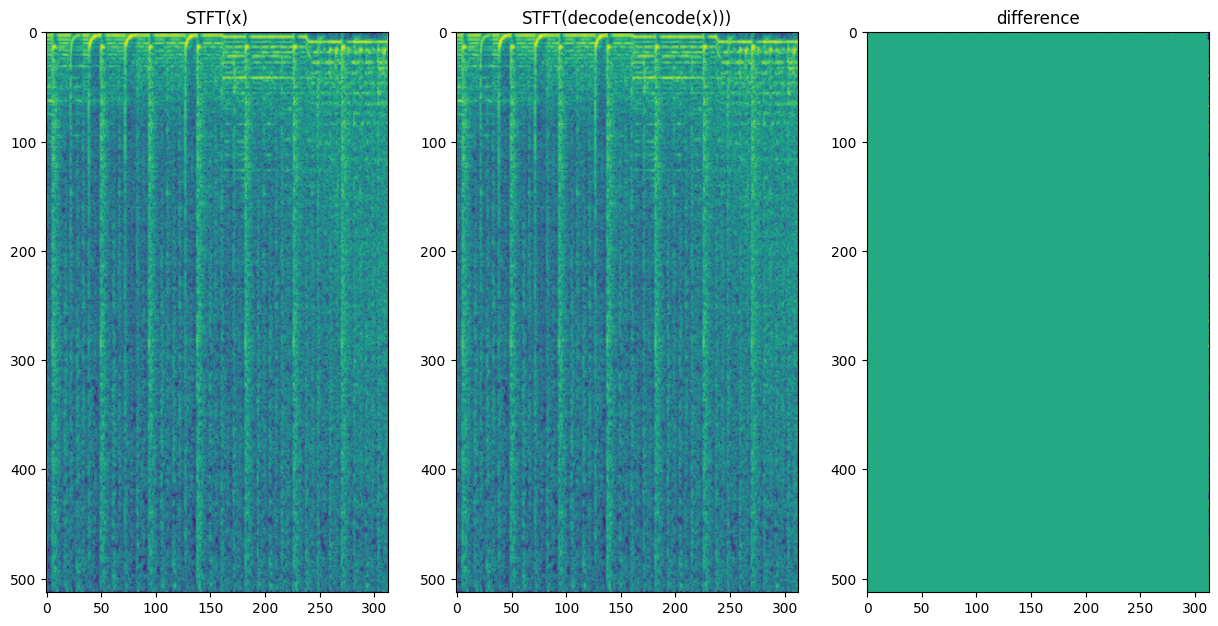

In [ ]:
def compute_log1p_stft(waveform:torch.Tensor, n_bits:int=8) -> torch.Tensor:
    """compute log1p stft and return spectrogram"""
    spectrograms = stft.compute_log1p_magnitude(waveform, n_bits=n_bits).unsqueeze(0)
    return spectrograms

stft_wav = compute_log1p_stft(wav)
stft_rec = compute_log1p_stft(reconstructed_wav)
diff = stft_rec - stft_wav

f, axes = plt.subplots(1, 3, figsize=(15, 20))
axes[0].imshow(stft_wav[0,0,0])
axes[1].imshow(stft_rec[0,0,0])
axes[2].imshow(diff[0,0,0])

axes[0].set_title("STFT(x)")
axes[1].set_title("STFT(decode(encode(x)))")
axes[2].set_title("difference")

In [ ]:
n_iters = 50
mag = sinc.magnitude(spec)
mag_mulaw = mu_law_compand(mag, q_bits=q_bits)
rspec = sinc.griffin_lim(mag, n_iters=n_iters)
rwav = sinc.decode(rspec)

rmag = sinc.magnitude(rspec)
rmag_mulaw = mu_law_compand(rmag, q_bits=q_bits)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(mag_mulaw[0,0].cpu().numpy())
axes[0].set_title("Magnitude Spectrogram")
axes[1].imshow(rmag_mulaw[0,0].cpu().numpy())
axes[1].set_title("Reconstructed Spectrogram")

ipd.Audio(rwav.cpu().numpy(), rate=SAMPLE_RATE, autoplay=False)

## 2 - Linearity Test

In [ ]:
audio_pathes = {
    0:"audio/stems/stem_pad.wav",
    1:"audio/stems/stem_drum1.wav",
    2:"audio/stems/stem_drum2.wav",

}

selection = [0,2]

wavs = []
for choice in selection:
    audio_path = audio_pathes[choice]
    waveform = audio_loader.load_segment(audio_path, offset=0, duration=5, nchannels=1)
    wavs.append(waveform)

mix = sum(wavs)
wavs.insert(0, mix)

plt.plot(mix[0])
ipd.Audio(mix, rate=SAMPLE_RATE, autoplay=False)

In [ ]:
spectrograms = []
reconstructed = []

with torch.no_grad():
    for i, waveform in enumerate(wavs):
        x = torch.from_numpy(waveform).to(device)
        s = sinc.encode(x)
        spectrograms.append(s)
        wav = sinc.decode(s)
        reconstructed.append(wav)

        display(ipd.Audio(waveform, rate=SAMPLE_RATE, autoplay=False))

In [ ]:
s_mix_true = spectrograms[0]
s_mix_linear = torch.cat(spectrograms[1:], dim=0).sum(dim=0)
assert torch.allclose(s_mix_true, s_mix_linear, rtol=1e-2)